In [49]:
from typing import Dict, Any
import torch
import numpy as np
from model_ranking import TransferFeatureExtraction
from model_ranking import (
    TransferFeatureExtractionConfig,
)
from model_ranking import (
    get_NA_prediction_path,
)
from model_ranking import load_h5

from CCFV.utils.sliding_window_sampling import FeatureExtractor

In [50]:
config: Dict[str, Any] = {
    "target_datasets": [{"name": "EPFL"}],
    "source_models": [{"source_name": "EPFL", "model_name": "E_model5", "model_type": "UNet2D"}],
    "source_model_base_path": "/g/kreshuk/talks/segmentation_ModelSelection/experiments",
    "data_base_path": "/scratch/talks/data",
    "feature_cfg": {
        "layers": ['decoders.2'],
        "sampling_seed": 42,
        "num_samples": 1000,
        "output_dir_path": None,
    }
}

In [51]:
feature_ranking_cfg = TransferFeatureExtractionConfig.model_validate(config)

In [52]:
feature_ranking = TransferFeatureExtraction(
    config=feature_ranking_cfg,
)

2025-08-11 15:19:36,849 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/EPFL/test.h5...
2025-08-11 15:19:36,849 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5599145293235779, global std: 0.11937469989061356
2025-08-11 15:19:37,523 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 0, 0)}
2025-08-11 15:19:37,530 [MainThread] INFO HDF5Dataset - Number of patches: 750


In [53]:
model = feature_ranking.initialise_model(
    feature_ranking.source_model_cfgs[0],
    feature_ranking.source_model_base_path,
)

/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location="cpu")


In [76]:
feature_extractor = FeatureExtractor(
    model=model,
    layers=["decoders.2"]
)
for target, target_dataset in feature_ranking.target_datasets.items():
    with torch.no_grad():
        for img, label in target_dataset:
            img = img.to("cuda:0")
            print(img.shape, label.shape)
            features_out, _, pred = feature_extractor(img)
            print(pred.shape)
            print(features_out['decoders.2'].shape) 
            break
feature_extractor.remove_handler()

torch.Size([1, 1, 256, 256]) torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])
torch.Size([1, 32, 256, 256])


In [77]:
from model_ranking import (
    load_h5,
)

path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria/EPFL_to_EPFL/E_model5_to_EPFL_features.h5"

predictions_precomputed = load_h5(path, "decoders.2_predictions")
indices = load_h5(path, "decoders.2_indices")

In [78]:
predictions_precomputed.shape

(750, 1000)

In [80]:
indices.shape

(750, 1000)

In [81]:
pred_sampled = np.reshape(pred.cpu().numpy(), -1)[indices[0]]
print(pred_sampled.shape)

(1000,)


In [82]:
import numpy as np
np.all(np.isclose(predictions_precomputed[0], pred_sampled, atol=1e-3))
# True

True

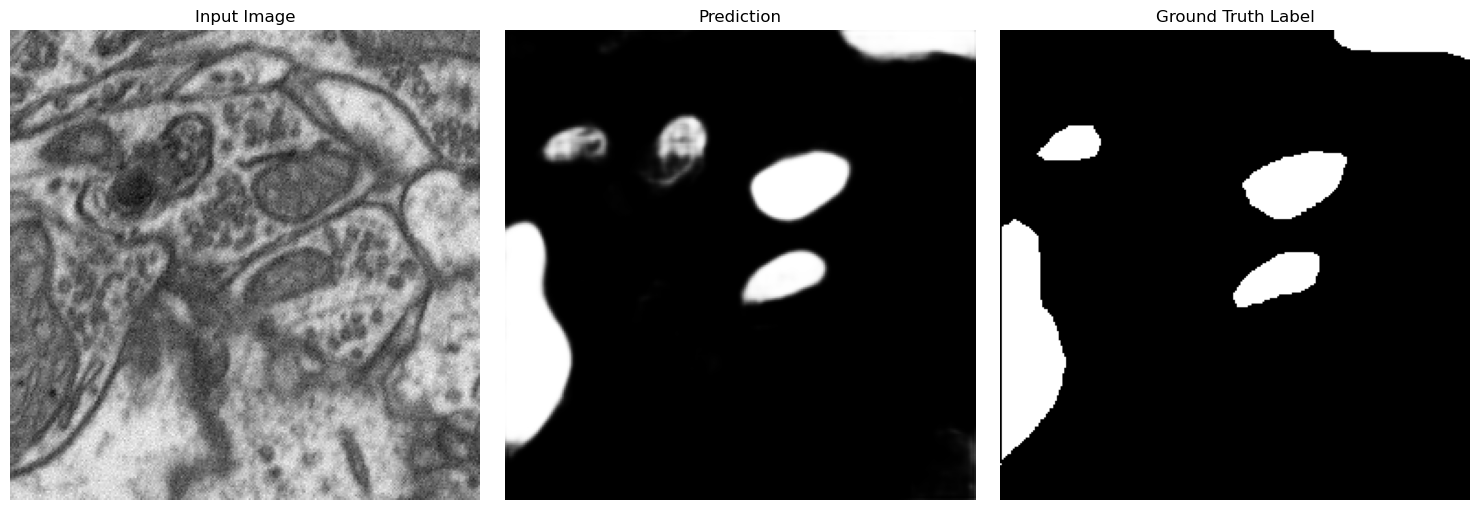

In [23]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot original image
axes[0].imshow(img.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title('Input Image')
axes[0].axis('off')

# Plot prediction
axes[1].imshow(pred.squeeze().cpu().detach().numpy(), cmap='gray')
axes[1].set_title('Prediction')
axes[1].axis('off')

# Plot ground truth label
axes[2].imshow(label.squeeze().cpu().numpy(), cmap='gray')
axes[2].set_title('Ground Truth Label')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [24]:
path = get_NA_prediction_path(
    model_name="E_model5",
    target="EPFL",
    base_path="/scratch/talks/consistency_results/patch_segmentation/mitochondria",
)

In [25]:
print(path)

/scratch/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/consistency/P_full/E_model5/norm_Normalize/none/predictions/test_predictions.h5


In [26]:
predictions = load_h5(path, "predictions")

In [27]:
predictions.shape

(750, 1, 1, 256, 256)

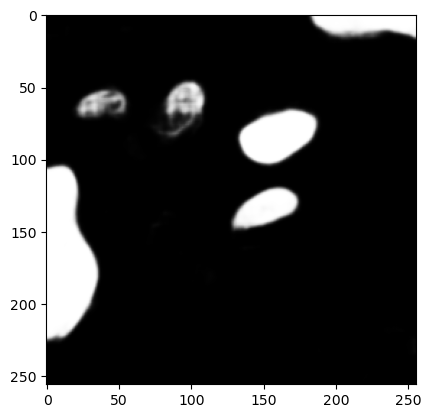

In [28]:
_ = plt.imshow(predictions[0].squeeze(), cmap='gray')
plt.show()

In [29]:
pred.shape

torch.Size([1, 1, 256, 256])

In [30]:
predictions[0].shape

(1, 1, 256, 256)

In [33]:
import numpy as np
print(np.all(np.equal(predictions[0]>0.5, pred.cpu().detach().numpy()>0.5)))

False


# compare features

In [44]:
from model_ranking import (
    load_h5,
    load_npz,
)

path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria/EPFL_to_EPFL/E_model5_to_EPFL_features"

features_npz = load_npz(path + ".npz", "decoders.2_features")
features_h5 = load_h5(path + ".h5", "decoders.2_features")

In [47]:
labels_npz = load_npz(path + ".npz", "decoders.2_labels")
labels_h5 = load_h5(path + ".h5", "decoders.2_labels")

In [58]:
indices_npz = load_npz(path + ".npz", "decoders.2_indices")
indices_h5 = load_h5(path + ".h5", "decoders.2_indices")
print(np.all(np.equal(indices_h5, indices_npz)))

True


In [48]:
np.all(np.equal(labels_h5, labels_npz))

True

In [46]:
np.allclose(features_npz, features_h5)

True

In [19]:
# Let's examine the structure of feature_in
print("Type of feature_in['decoders.2']:", type(feature_in['decoders.2']))
print("Length of tuple:", len(feature_in['decoders.2']))
print("Shape of first element:", feature_in['decoders.2'][0].shape)

# This is a tuple because PyTorch forward hooks always pass inputs as a tuple
# even when there's only one input tensor. This allows handling layers with multiple inputs.

Type of feature_in['decoders.2']: <class 'tuple'>
Length of tuple: 2
Shape of first element: torch.Size([1, 32, 256, 256])


In [20]:
# Let's examine both elements in the input tuple
print("First element shape:", feature_in['decoders.2'][0].shape)
print("Second element shape:", feature_in['decoders.2'][1].shape)
print("Second element type:", type(feature_in['decoders.2'][1]))

# The tuple likely contains multiple inputs to the decoder layer
# For example, skip connections in U-Net architectures

First element shape: torch.Size([1, 32, 256, 256])
Second element shape: torch.Size([1, 64, 128, 128])
Second element type: <class 'torch.Tensor'>
